#**IPL Cricket Analytics Project**


###**Project Overview**

This project analyzes IPL cricket data using Python, Pandas, NumPy, Matplotlib, and Seaborn. The objective is to uncover insights related to team performance, batting trends, bowling efficiency, toss impact, venue analysis, and match-winning patterns using ball-by-ball IPL data.

#IMPORT LIBRARIES

##Purpose

Import required Python libraries for data analysis and visualization.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#LOAD DATASETS
##Purpose

Load IPL match-level and ball-by-ball datasets into Python.

In [78]:
matches = pd.read_csv("/content/matches.csv")

deliveries = pd.read_csv("/content/deliveries.csv")

#DISPLAY FIRST 5 ROWS OF DATASETS
##Purpose

Check dataset structure and understand available columns.

In [79]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [80]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


#CHECK DATASET COLUMNS
##Purpose

Understand important columns before merging datasets.

In [81]:
print(matches.columns)

print(deliveries.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


#MERGE MATCHES AND DELIVERIES DATASETS
##Purpose

Combine match-level and ball-by-ball datasets using match identifiers

In [82]:
ipl = deliveries.merge(
    matches,
    left_on='match_id',
    right_on='id',
    how='inner'
)

##Insight

This merge creates a unified dataset containing player, team, venue, and match-level information.

#DISPLAY MERGED DATASET
##Purpose

Verify whether datasets merged successfully.

In [83]:
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen


#CREATE TOTAL RUNS FEATURE
##Purpose

Calculate total runs scored on every delivery.

In [84]:
ipl['total_runs'] = (
    ipl['batsman_runs']
    + ipl['extra_runs']
)

#MOST SUCCESSFUL IPL TEAMS ANALYSIS
##Purpose

Identify teams with the highest number of wins.

In [85]:
team_wins = ipl['winner'].value_counts()

team_wins

,count
winner,
Mumbai Indians,34629
Chennai Super Kings,33388
Kolkata Knight Riders,30820
Royal Challengers Bangalore,27319
Rajasthan Royals,27029
Kings XI Punjab,20948
Sunrisers Hyderabad,20946
Delhi Daredevils,15709
Delhi Capitals,11641


#VISUALIZATION OF TEAM WINS
##Purpose

Visualize team performance using bar charts.

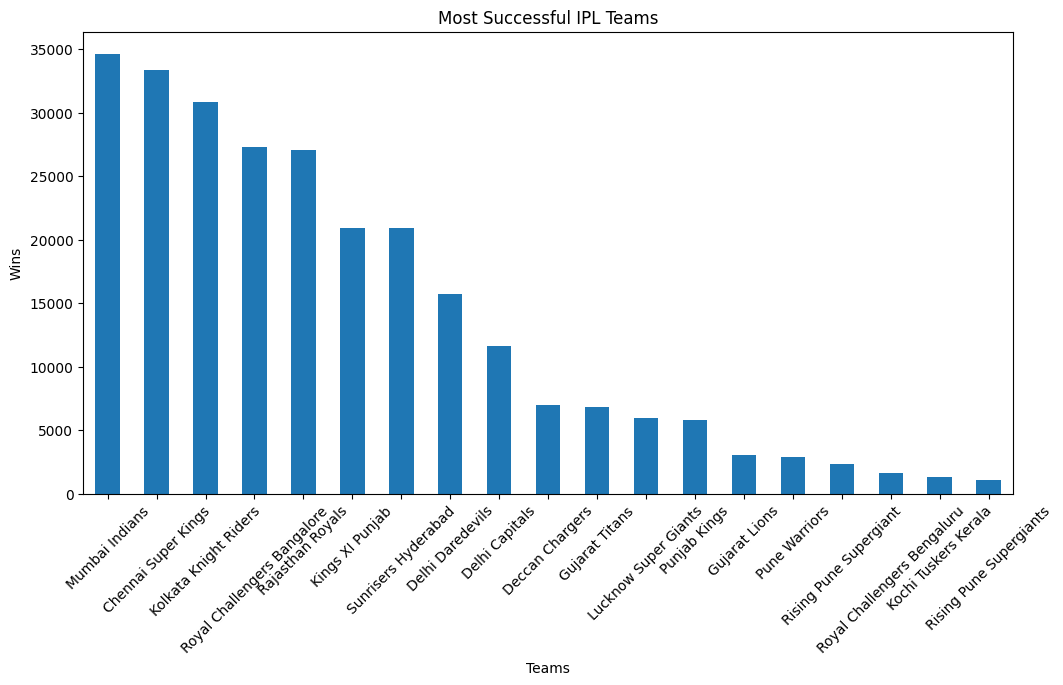

In [86]:
plt.figure(figsize=(12,6))
team_wins.plot(kind='bar')
plt.title('Most Successful IPL Teams')
plt.xlabel('Teams')
plt.ylabel('Wins')
plt.xticks(rotation=45)

plt.show()

#TOP RUN SCORERS ANALYSIS
##Purpose

Identify the highest run-scoring batters in IPL history.

In [87]:
runs = ipl.groupby(
    'batter'
)['batsman_runs'].sum().sort_values(
    ascending=False
).head(10)

runs

,batsman_runs
batter,
V Kohli,8014
S Dhawan,6769
RG Sharma,6630
DA Warner,6567
SK Raina,5536
MS Dhoni,5243
AB de Villiers,5181
CH Gayle,4997
RV Uthappa,4954


#VISUALIZATION OF TOP RUN SCORERS
##Purpose

Visualize the top-performing batters.

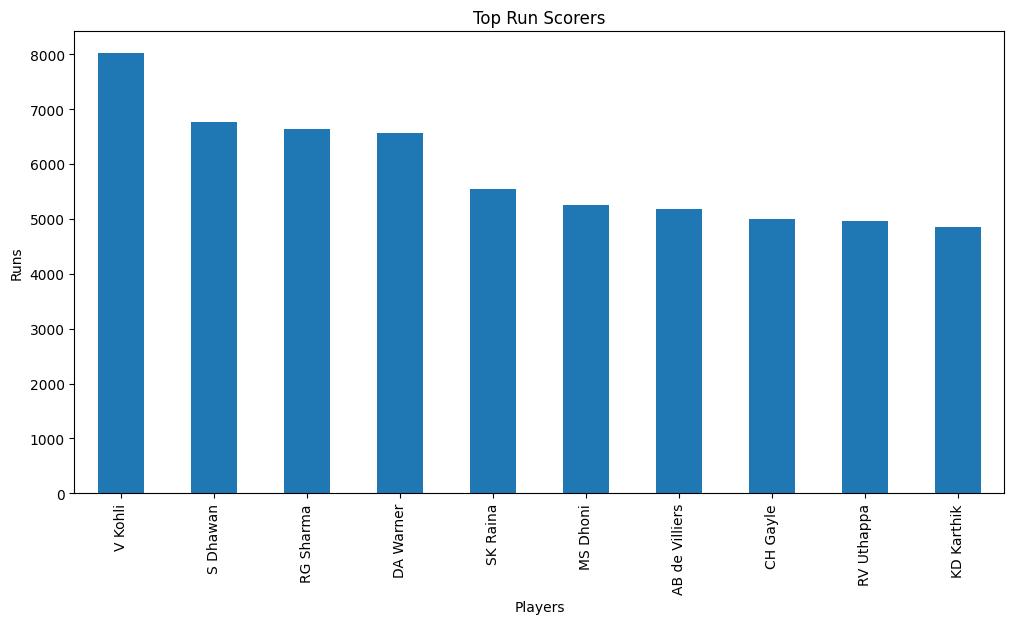

In [88]:
plt.figure(figsize=(12,6))
runs.plot(kind='bar')
plt.title('Top Run Scorers')
plt.xlabel('Players')
plt.ylabel('Runs')

plt.show()

#TOP WICKET TAKERS ANALYSIS
##Purpose

Identify bowlers with the highest wickets in IPL history.

In [89]:
wickets = ipl[
    ipl['dismissal_kind'].notnull()
]

wicket_count = wickets.groupby(
    'bowler'
).size().sort_values(
    ascending=False
).head(10)

wicket_count

,0
bowler,
YS Chahal,213
DJ Bravo,207
PP Chawla,201
SP Narine,200
R Ashwin,198
B Kumar,195
SL Malinga,188
A Mishra,183
JJ Bumrah,182


#VISUALIZATION OF TOP WICKET TAKERS
##Purpose

Visualize bowling performance using bar charts.

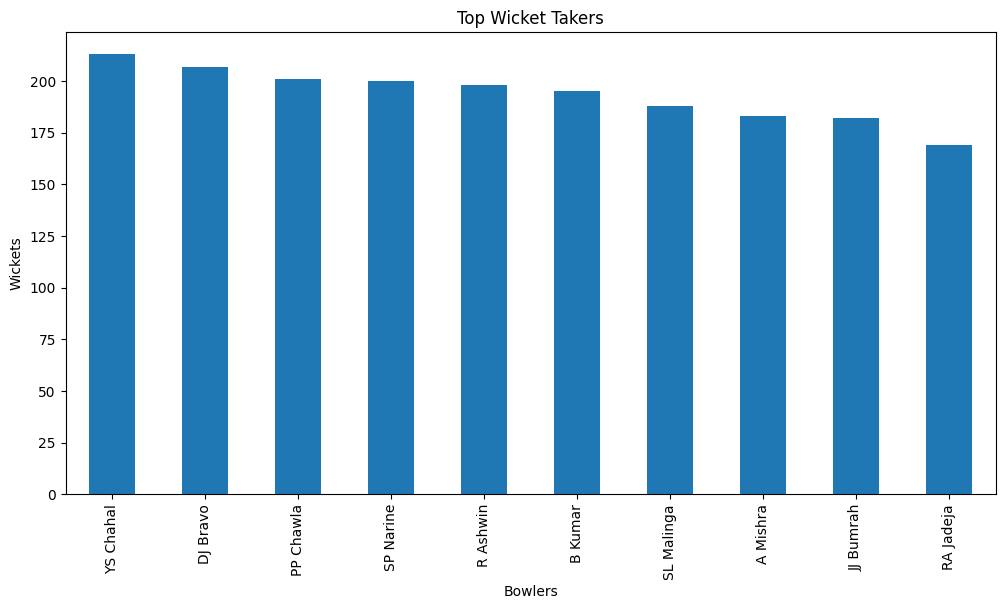

In [90]:
plt.figure(figsize=(12,6))
wicket_count.plot(kind='bar')
plt.title('Top Wicket Takers')
plt.xlabel('Bowlers')
plt.ylabel('Wickets')

plt.show()

#TOSS IMPACT ANALYSIS
##Purpose

Analyze how often toss winners also win the match.

In [91]:
toss_match = ipl[
    ipl['toss_winner']
    == ipl['winner']
]

impact = (
    len(toss_match)
    / len(ipl)
) * 100

print(impact)

50.334968572742596


#SEASON-WISE RUNS ANALYSIS
##Purpose

Analyze scoring trends across IPL seasons.

In [92]:
season_runs = ipl.groupby(
    'season'
)['total_runs'].sum()

season_runs

,total_runs
season,
2007/08,17937
2009,16353
2009/10,18883
2011,21154
2012,22453
2013,22602
2014,18931
2015,18353
2016,18862


#Visualization

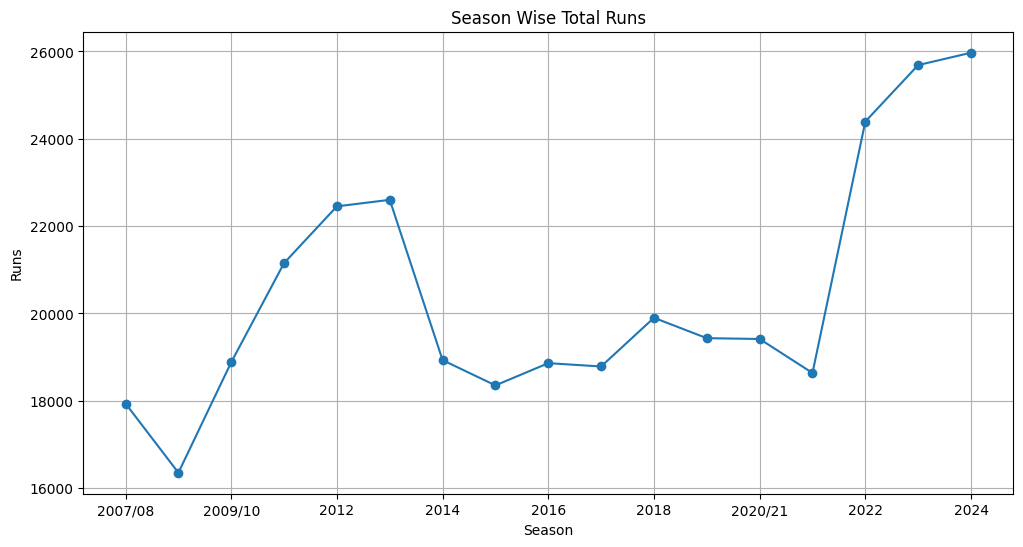

In [93]:
plt.figure(figsize=(12,6))

season_runs.plot(
    kind='line',
    marker='o'
)

plt.title('Season Wise Total Runs')
plt.xlabel('Season')
plt.ylabel('Runs')
plt.grid(True)

plt.show()

#Toss Decision Analysis
##Purpose

Analyze whether teams prefer batting or bowling after winning the toss.

In [94]:
toss_decision = matches[
    'toss_decision'
].value_counts()

toss_decision

,count
toss_decision,
field,704
bat,391


#Visualization

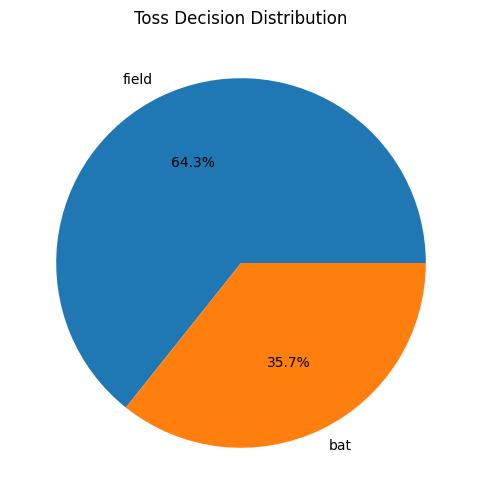

In [95]:
plt.figure(figsize=(6,6))
toss_decision.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Toss Decision Distribution')

plt.show()

#VENUE ANALYSIS
##Purpose

Identify high-scoring IPL venues

In [96]:
venue_scores = ipl.groupby(
    'venue'
)['total_runs'].mean().sort_values(
    ascending=False
).head(10)

venue_scores

,total_runs
venue,
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",1.600000
"Eden Gardens, Kolkata",1.577242
"M Chinnaswamy Stadium, Bengaluru",1.554777
"Himachal Pradesh Cricket Association Stadium, Dharamsala",1.542770
"Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh",1.537697
"Arun Jaitley Stadium, Delhi",1.536967
"Rajiv Gandhi International Stadium, Uppal, Hyderabad",1.509548
M.Chinnaswamy Stadium,1.467373
Holkar Cricket Stadium,1.461578


#Visualization

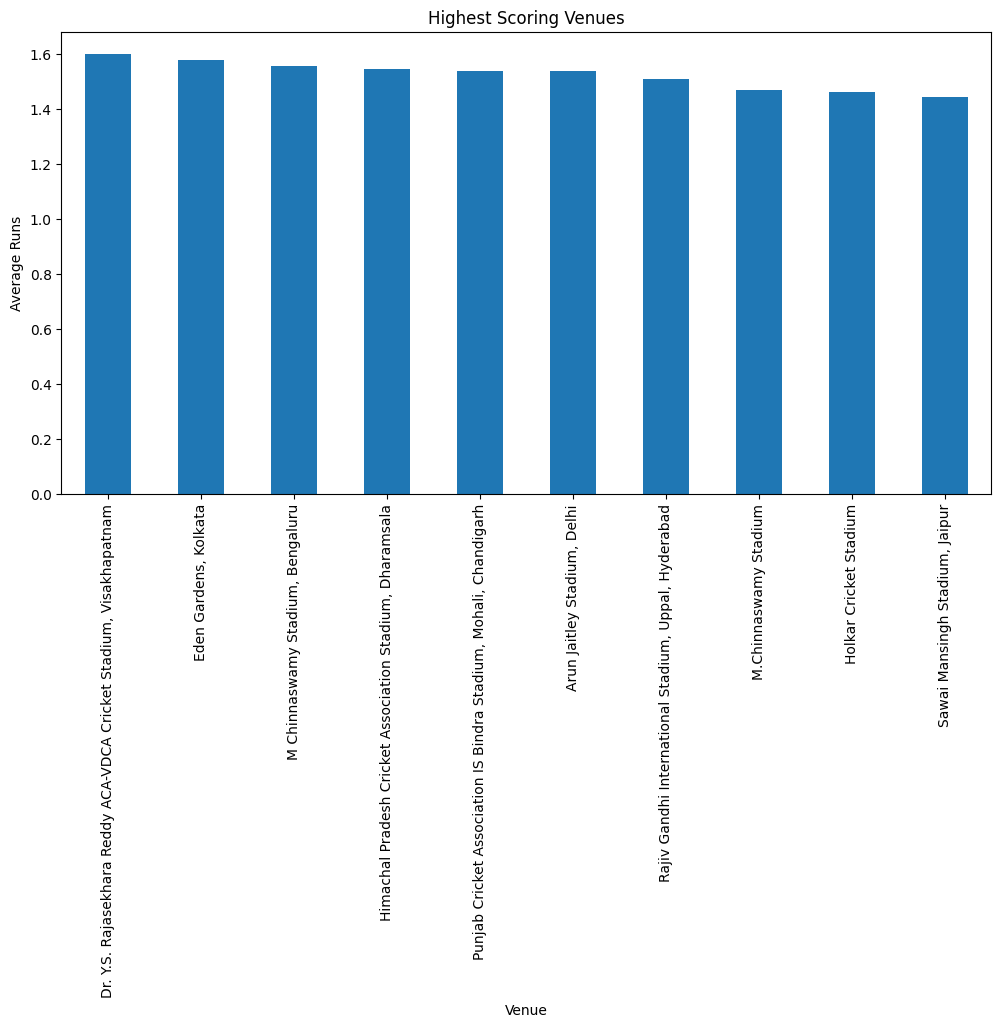

In [97]:
plt.figure(figsize=(12,6))
venue_scores.plot(kind='bar')
plt.title('Highest Scoring Venues')
plt.xlabel('Venue')
plt.ylabel('Average Runs')

plt.show()

#Chasing vs Defending Analysis
##Purpose

Compare match outcomes while chasing versus defending targets

In [98]:
matches['result'] = np.where(
    matches['winner']
    == matches['team2'],
    'Chasing',
    'Defending'
)

result_analysis = matches[
    'result'
].value_counts()

result_analysis

,count
result,
Defending,560
Chasing,535


#Visualization

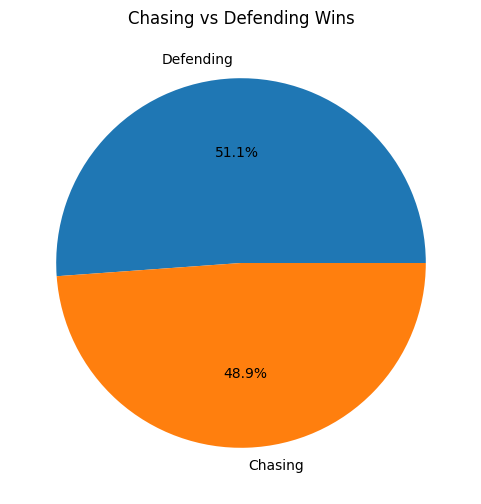

In [99]:
plt.figure(figsize=(6,6))
result_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Chasing vs Defending Wins')

plt.show()

# Best Strike Rates

##Minimum 1000 runs

In [100]:
batsman = ipl.groupby(
    'batter'
).agg({
    'batsman_runs':'sum',
    'ball':'count'
})

batsman = batsman[
    batsman['batsman_runs'] > 1000
]

batsman['strike_rate'] = (
    batsman['batsman_runs']
    / batsman['ball']
) * 100

batsman = batsman.sort_values(
    by='strike_rate',
    ascending=False
).head(10)

batsman

,batsman_runs,ball,strike_rate
batter,,,
AD Russell,2488,1515,164.224422
SP Narine,1534,984,155.894309
N Pooran,1769,1143,154.768154
GJ Maxwell,2772,1842,150.488599
Abhishek Sharma,1377,925,148.864865
V Sehwag,2728,1833,148.827059
AB de Villiers,5181,3487,148.580442
YBK Jaiswal,1607,1095,146.757991
SO Hetmyer,1243,854,145.550351


#Best Economy Bowlers

##Minimum 500 balls

In [101]:
bowler = ipl.groupby(
    'bowler'
).agg({
    'total_runs':'sum',
    'ball':'count'
})

bowler = bowler[
    bowler['ball'] > 500
]

bowler['overs'] = (
    bowler['ball'] / 6
)

bowler['economy'] = (
    bowler['total_runs']
    / bowler['overs']
)

best_economy = bowler.sort_values(
    by='economy'
).head(10)

best_economy

,total_runs,ball,overs,economy
bowler,,,,
A Kumble,1089,983,163.833333,6.646999
M Muralitharan,1765,1581,263.500000,6.698292
SP Narine,4672,4146,691.000000,6.761216
DW Steyn,2583,2282,380.333333,6.791411
DL Vettori,894,785,130.833333,6.833121
Rashid Khan,3340,2901,483.500000,6.907963
J Botha,818,709,118.166667,6.922426
R Ashwin,5435,4679,779.833333,6.969438
MM Ali,900,770,128.333333,7.012987


#FEATURE ENGINEERING
##Purpose

Create advanced analytical features for deeper insights.

#CREATE BOUNDARY FEATURE
##Purpose

Identify deliveries resulting in boundaries.

In [138]:
ipl['is_boundary'] = np.where(
    ipl['batsman_runs'].isin([4,6]),
    1,
    0
)


In [104]:
batter_stats = ipl.groupby(
    'batter'
).agg({
    'batsman_runs':'sum',
    'ball':'count',
    'is_boundary':'sum'
})

batter_stats['boundary_percent'] = (
    batter_stats['is_boundary']
    / batter_stats['ball']
) * 100

batter_stats = batter_stats[
    batter_stats['batsman_runs'] > 2000
]

batter_stats.sort_values(
    by='boundary_percent',
    ascending=False
).head(10)

,batsman_runs,ball,is_boundary,boundary_percent
batter,,,,
AD Russell,2488,1515,380,25.082508
V Sehwag,2728,1833,440,24.004364
CH Gayle,4997,3516,767,21.814562
GJ Maxwell,2772,1842,393,21.335505
AC Gilchrist,2069,1555,331,21.286174
JC Buttler,3583,2519,517,20.524017
SA Yadav,3594,2522,515,20.420301
DR Smith,2385,1803,362,20.077648
RR Pant,3297,2296,452,19.686411


#CREATE DOT BALL FEATURE
##Purpose

Identify deliveries where no runs were scored.

In [103]:
ipl['is_dot'] = np.where(
    ipl['total_runs'] == 0,
    1,
    0
)

In [105]:
bowler_stats = ipl.groupby(
    'bowler'
).agg({
    'ball':'count',
    'is_dot':'sum'
})

bowler_stats = bowler_stats[
    bowler_stats['ball'] > 500
]

bowler_stats['dot_ball_percent'] = (
    bowler_stats['is_dot']
    / bowler_stats['ball']
) * 100

bowler_stats.sort_values(
    by='dot_ball_percent',
    ascending=False
).head(10)

,ball,is_dot,dot_ball_percent
bowler,,,
DW Steyn,2282,1019,44.653812
MM Patel,1382,590,42.691751
JC Archer,987,420,42.553191
DE Bollinger,600,254,42.333333
S Sreesanth,947,399,42.133052
RJ Harris,865,364,42.080925
M Morkel,1699,708,41.671572
JR Hazlewood,622,259,41.639871
DP Nannes,689,285,41.364296


# CREATE MATCH PHASE FEATURE

## Purpose

Divide innings into Powerplay,
Middle Overs, and Death Overs.

In [106]:
def phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle Overs'
    else:
        return 'Death Overs'

ipl['phase'] = ipl['over'].apply(phase)

# PHASE-WISE SCORING ANALYSIS

## Purpose

Analyze scoring trends across
different match phases.

In [107]:
phase_runs = ipl.groupby(
    'phase'
)['total_runs'].sum()

phase_runs

,total_runs
phase,
Death Overs,75412
Middle Overs,154288
Powerplay,118056


# VISUALIZATION OF PHASE-WISE RUNS

## Purpose

Visualize runs scored in Powerplay,
Middle Overs, and Death Overs.

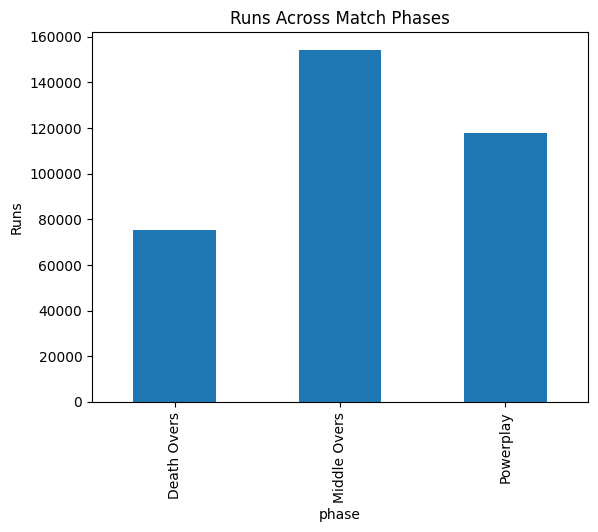

In [108]:
phase_runs.plot(kind='bar')
plt.title('Runs Across Match Phases')
plt.ylabel('Runs')

plt.show()

# DEATH OVERS BATTING ANALYSIS

## Purpose

Identify the best finishers and
high-pressure batters in IPL.

In [109]:
death_overs = ipl[
    ipl['phase'] == 'Death Overs'
]

death_batters = death_overs.groupby(
    'batter'
)['batsman_runs'].sum().sort_values(
    ascending=False
).head(10)

death_batters

,batsman_runs
batter,
MS Dhoni,2786
KA Pollard,1708
KD Karthik,1565
AB de Villiers,1421
RA Jadeja,1420
RG Sharma,1176
HH Pandya,1126
V Kohli,1099
AD Russell,1065


# PLAYER CONSISTENCY ANALYSIS

## Purpose

Measure average runs scored per match
to identify consistent batters.

## Insight

Consistent players contribute more
reliably to team success.

In [110]:
player_match_runs = ipl.groupby(
    ['batter','match_id']
)['batsman_runs'].sum().reset_index()

consistency = player_match_runs.groupby(
    'batter'
)['batsman_runs'].mean().sort_values(
    ascending=False
).head(10)

consistency

,batsman_runs
batter,
Vivrant Sharma,69.000000
DP Conway,42.000000
B Sai Sudharsan,41.360000
KL Rahul,38.434426
LMP Simmons,37.206897
J Fraser-McGurk,36.666667
RD Gaikwad,36.615385
SE Marsh,36.072464
HM Amla,36.062500


# TEAM DEPENDENCY ANALYSIS

## Purpose

Analyze which teams rely heavily
on individual players for scoring.

## Insight

Certain teams are highly dependent
on star players for run production.

In [111]:
team_player_runs = ipl.groupby(
    ['batting_team','batter']
)['batsman_runs'].sum().reset_index()

team_totals = ipl.groupby(
    'batting_team'
)['batsman_runs'].sum().reset_index()

dependency = pd.merge(
    team_player_runs,
    team_totals,
    on='batting_team'
)

dependency['dependency_percent'] = (
    dependency['batsman_runs_x']
    / dependency['batsman_runs_y']
) * 100

dependency.sort_values(
    by='dependency_percent',
    ascending=False
).head(10)

,batting_team,batter,batsman_runs_x,batsman_runs_y,dependency_percent
1200,Royal Challengers Bengaluru,V Kohli,741,2789,26.568663
1023,Rising Pune Supergiants,AM Rahane,480,1962,24.464832
344,Gujarat Titans,Shubman Gill,1799,7357,24.452902
1172,Royal Challengers Bangalore,V Kohli,7273,35810,20.309969
464,Kochi Tuskers Kerala,BB McCullum,357,1758,20.307167
1020,Rising Pune Supergiant,SPD Smith,472,2370,19.915612
622,Lucknow Super Giants,KL Rahul,1410,7081,19.912442
806,Pune Warriors,RV Uthappa,1103,6040,18.261589
321,Gujarat Lions,SK Raina,841,4629,18.168071
466,Kochi Tuskers Kerala,DPMD Jayawardene,299,1758,17.007964


# VENUE ADVANTAGE ANALYSIS

## Purpose

Identify teams performing strongly
at specific IPL venues.

## Insight

Home venue familiarity significantly
improves team performance.

In [112]:
venue_advantage = matches.groupby(
    ['venue','winner']
).size().reset_index(name='wins')

venue_advantage.sort_values(
    by='wins',
    ascending=False
).head(10)

,venue,winner,wins
88,Eden Gardens,Kolkata Knight Riders,45
360,Wankhede Stadium,Mumbai Indians,42
169,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,33
300,Sawai Mansingh Stadium,Rajasthan Royals,32
152,M Chinnaswamy Stadium,Royal Challengers Bangalore,29
104,Feroz Shah Kotla,Delhi Daredevils,23
272,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,20
249,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,18
260,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,10
89,Eden Gardens,Mumbai Indians,10


# WINNING PATTERN ANALYSIS

## Purpose

Compare batting-first wins
versus chasing wins.

In [113]:
matches['win_type'] = np.where(
    matches['winner'] == matches['team1'],
    'Bat First',
    'Chasing'
)

matches['win_type'].value_counts()

,count
win_type,
Bat First,555
Chasing,540


# VISUALIZATION OF WINNING PATTERNS

## Purpose

Visualize IPL winning patterns
using a pie chart.

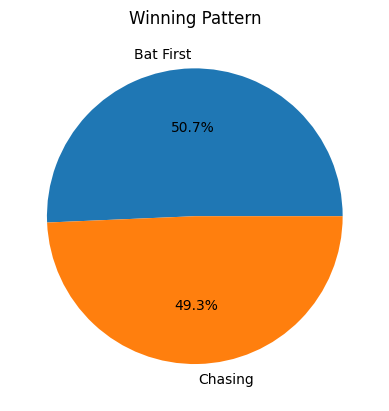

In [114]:
matches['win_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel('')
plt.title('Winning Pattern')

plt.show()

# DEATH OVERS BOWLING ANALYSIS

## Purpose

Identify bowlers with the best
economy rates in death overs.

## Insight

Economical death-over bowlers play
a critical role in controlling matches.

In [115]:
death_bowling = ipl[
    ipl['phase'] == 'Death Overs'
]

death_bowler_stats = death_bowling.groupby(
    'bowler'
).agg({
    'total_runs':'sum',
    'ball':'count'
})

death_bowler_stats['economy'] = (
    death_bowler_stats['total_runs']
    / (death_bowler_stats['ball']/6)
)

death_bowler_stats.sort_values(
    by='economy'
).head(10)

,total_runs,ball,economy
bowler,,,
AC Gilchrist,0,1,0.000000
MP Yadav,0,1,0.000000
ND Doshi,1,6,1.000000
MJ Santner,1,6,1.000000
DJ Muthuswami,1,6,1.000000
SE Rutherford,2,5,2.400000
S Rana,2,4,3.000000
L Ablish,4,7,3.428571
N Burger,13,19,4.105263


# CORRELATION ANALYSIS

## Purpose

Analyze relationships between
important numerical variables.

In [116]:
numeric_cols = [
    'batsman_runs',
    'extra_runs',
    'total_runs',
    'is_boundary',
    'is_dot'
]
correlation = ipl[
    numeric_cols
].corr()

correlation

,batsman_runs,extra_runs,total_runs,is_boundary,is_dot
batsman_runs,1.000000,-0.142079,0.977934,0.904734,-0.562044
extra_runs,-0.142079,1.000000,0.067852,-0.080968,-0.143872
total_runs,0.977934,0.067852,1.000000,0.894811,-0.596860
is_boundary,0.904734,-0.080968,0.894811,1.000000,-0.323089
is_dot,-0.562044,-0.143872,-0.596860,-0.323089,1.000000


# CORRELATION HEATMAP

## Purpose

Visualize feature correlations
using a heatmap.

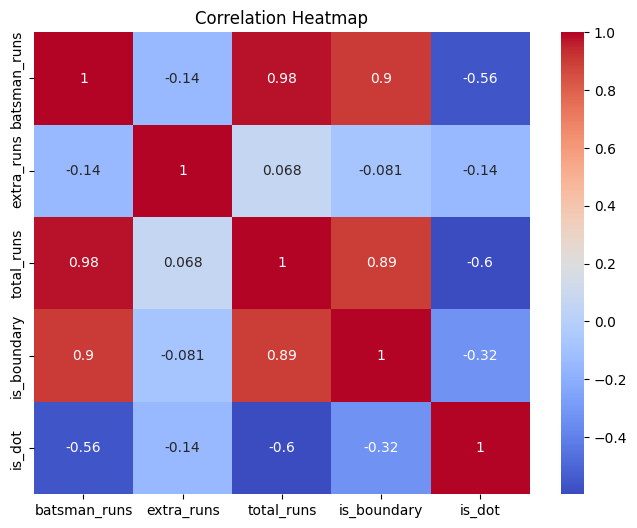

In [117]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

#MACHINE LEARNING MODEL
##Purpose

Predict IPL match winners using historical match data.

# IMPORT MACHINE LEARNING LIBRARIES

## Purpose

Import libraries required for
IPL match prediction modeling.

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# SELECT IMPORTANT FEATURES

## Purpose

Select match-related variables
for machine learning prediction.

In [119]:
ml_data = matches[[
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'venue',
    'winner'
]]

# REMOVE NULL VALUES

## Purpose

Remove missing values before
training the machine learning model.

In [120]:
ml_data = ml_data.dropna()

# DISPLAY MACHINE LEARNING DATA

## Purpose

Verify processed machine learning dataset.

In [121]:
ml_data.head()

,team1,team2,toss_winner,toss_decision,venue,winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Daredevils
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,Kolkata Knight Riders


# LABEL ENCODING

## Purpose

Convert categorical text data
into numerical format.

In [122]:
encoder = LabelEncoder()
for column in ml_data.columns:

    ml_data[column] = encoder.fit_transform(
        ml_data[column]
    )

# DEFINE FEATURES AND TARGET

## Purpose

Separate independent variables
and target variable.

In [123]:
X = ml_data.drop(
    'winner',
    axis=1
)
y = ml_data['winner']

# TRAIN TEST SPLIT

## Purpose

Split dataset into training
and testing sets.

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# BUILD RANDOM FOREST MODEL

## Purpose

Create a Random Forest classifier
for IPL match prediction.

In [125]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# TRAIN MACHINE LEARNING MODEL

## Purpose

Train prediction model using
historical IPL match data.

In [126]:
model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

# MAKE MATCH PREDICTIONS

## Purpose

Predict IPL match winners
on unseen test data.

In [127]:
predictions = model.predict(
    X_test
)

# MODEL ACCURACY EVALUATION

## Purpose

Measure prediction accuracy
of the machine learning model.

In [128]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print(
    f'Accuracy: {accuracy:.2f}'
)

Accuracy: 0.48


# CLASSIFICATION REPORT

## Purpose

Evaluate model precision,
recall, and F1-score.

In [129]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.68      0.62      0.65        37
           1       0.50      1.00      0.67         2
           2       0.20      0.14      0.17         7
           3       0.46      0.46      0.46        13
           4       0.50      0.40      0.44         5
           5       0.33      0.11      0.17         9
           6       0.37      0.41      0.39        17
           7       0.00      0.00      0.00         2
           8       0.50      0.52      0.51        23
           9       0.40      0.67      0.50         3
          10       0.50      0.54      0.52        26
          11       0.33      0.33      0.33         3
          12       0.00      0.00      0.00         3
          13       0.56      0.56      0.56        25
          14       0.50      0.25      0.33         4
          16       0.37      0.38      0.38        26
          17       0.00      0.00      0.00         2
          18       0.42    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# CONFUSION MATRIX

## Purpose

Analyze prediction performance
across different classes.

In [130]:
cm = confusion_matrix(
    y_test,
    predictions
)
cm

array([[23,  0,  1,  1,  0,  1,  4,  0,  0,  1,  0,  0,  0,  0,  0,  4,
         0,  2],
       [ 0,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0],
       [ 1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  1,  1,  0,  0,
         0,  2],
       [ 0,  0,  0,  6,  1,  0,  3,  0,  0,  0,  1,  1,  0,  1,  0,  0,
         0,  0],
       [ 0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  1,
         0,  0],
       [ 1,  0,  2,  0,  0,  1,  0,  0,  1,  0,  0,  0,  0,  3,  0,  1,
         0,  0],
       [ 0,  0,  1,  2,  1,  0,  7,  0,  1,  0,  0,  0,  0,  1,  0,  3,
         0,  1],
       [ 0,  0,  0,  0,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,
         0,  0],
       [ 1,  2,  0,  0,  0,  1,  0,  0, 12,  1,  3,  0,  0,  0,  0,  1,
         0,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  0,
         1,  0],
       [ 4,  0,  0,  1,  0,  0,  1,  0,  2,  0, 14,  0,  0,  2,  0,  1,
         0,  1],
       [ 0,  0,  0,  

# VISUALIZATION OF CONFUSION MATRIX

## Purpose

Visualize prediction accuracy
using heatmap representation.

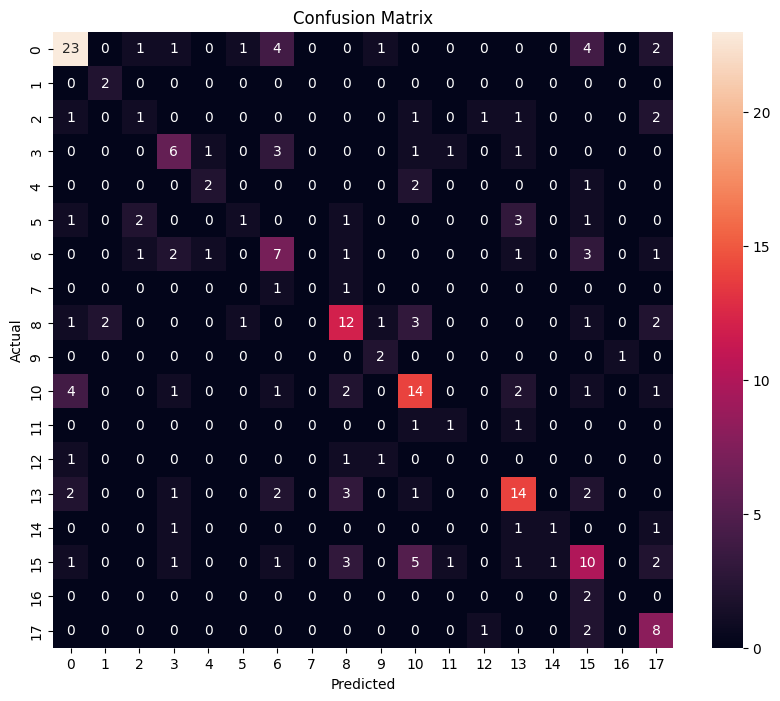

In [131]:
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# FEATURE IMPORTANCE ANALYSIS

## Purpose

Identify the most influential
features affecting match outcomes.

## Insight

Venue and toss decisions strongly
influence IPL match results.

In [132]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance.sort_values(
    ascending=False
)

,0
venue,0.264935
team1,0.252102
team2,0.243166
toss_winner,0.185949
toss_decision,0.053848


# VISUALIZATION OF FEATURE IMPORTANCE

## Purpose

Visualize important match-winning
factors in IPL prediction.

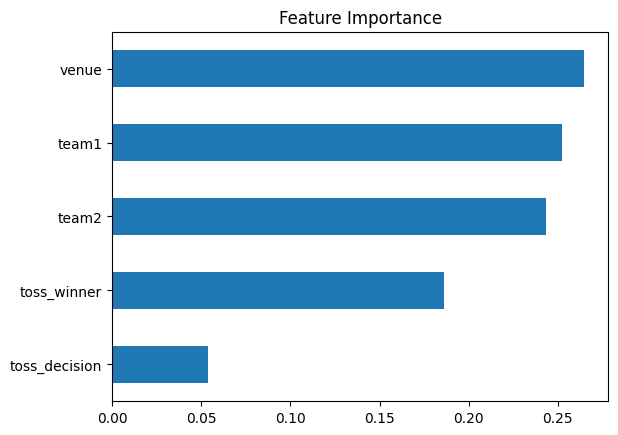

In [133]:
importance.sort_values().plot(
    kind='barh'
)
plt.title('Feature Importance')
plt.show()

# CUSTOM MATCH PREDICTION

## Purpose

Predict outcome for a custom
IPL match scenario.

In [140]:
sample = pd.DataFrame([[
    0,
    1,
    0,
    1,
    5
]], columns=X.columns)

prediction = model.predict(sample)

print("Predicted Winner Code:", prediction[0])

Predicted Winner Code: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

# PROJECT CONCLUSION

This IPL Cricket Analytics project successfully analyzed historical IPL match and ball-by-ball data using Python, Pandas, NumPy, Matplotlib, and Machine Learning techniques.

Key achievements:
- Performed data cleaning and preprocessing
- Conducted exploratory data analysis (EDA)
- Built advanced cricket KPIs
- Analyzed batting and bowling performance
- Studied toss impact and venue trends
- Developed a Random Forest match prediction model
- Generated business insights using data visualization

The project demonstrates end-to-end Data Analytics workflow including feature engineering, statistical analysis, visualization, and predictive modeling.